In [5]:
from astropy.table import Table, vstack
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import fitsio
import healpy
from scipy.spatial import cKDTree
from astropy.cosmology import Planck18 as cosmo
from mpl_toolkits.mplot3d import Axes3D
import astropy.units as u
import astropy.constants as const
import matplotlib
import matplotlib.patheffects as pe
from math import log10, floor
import scipy.stats

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [6]:
L = "40"
R = "1"
figtag = "R"+R+"L"+L

In [7]:
'''sv3elg = Table.read("datafiles/SV3_"+figtag+"_elg.csv",format="csv")
sv3lrg = Table.read("datafiles/SV3_"+figtag+"_lrg.csv",format="csv")'''

#now using LSS
sv3elg = Table.read("datafiles/SV3cleaned_R1L40_elg.csv")
sv3lrg = Table.read("datafiles/SV3cleaned_R1L40_lrg.csv")

In [8]:
mock0elg = Table.read("datafiles/mock0_"+figtag+"_elg.csv",format="csv")
mock0lrg = Table.read("datafiles/mock0_"+figtag+"_lrg.csv",format="csv")
mockRocherelg = Table.read("datafiles/RocherMock1L40_elg.csv",format='csv')
mockRocherlrg = Table.read("datafiles/RocherMock1L40_lrg.csv",format='csv')
mockUchuulrg = Table.read("datafiles/Uchuu_"+figtag+"_lrg.csv",format='csv')
mockZhangelg = Table.read("datafiles/Zhang_"+figtag+"_elg.csv",format="csv")
mockZhanglrg = Table.read("datafiles/Zhang_"+figtag+"_lrg.csv",format="csv")

In [9]:
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(5,10):
    mockselg.append(Table.read("datafiles/MockCompleteDownsampled"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/MockCompleteDownsampled"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg = vstack(mockselg)
combined_lrg = vstack(mockslrg)

In [10]:
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(5):
    mockselg.append(Table.read("datafiles/forFA"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/forFA"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg_forFA = vstack(mockselg)
combined_lrg_forFA = vstack(mockslrg)

In [11]:
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(18):
    mockselg.append(Table.read("datafiles/AurelioNoImmask"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/AurelioNoImmask"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg_noimmask = vstack(mockselg)
combined_lrg_noimmask = vstack(mockslrg)

In [12]:
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(18):
    mockselg.append(Table.read("datafiles/AurelioWithHoles"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/AurelioWithHoles"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg_withholes = vstack(mockselg)
combined_lrg_withholes = vstack(mockslrg)

KeyboardInterrupt: 

In [ ]:
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(16):
    mockselg.append(Table.read("datafiles/AurelioCiCHoleClean"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/AurelioCiCHoleClean"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg_holeclean = vstack(mockselg)
combined_lrg_holeclean = vstack(mockslrg)

In [3]:
#forFA, with ebits
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(10):
    mockselg.append(Table.read("datafiles/forFA_ebits_"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/forFA_ebits_"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg_forFAebits = vstack(mockselg)
combined_lrg_forFAebits = vstack(mockslrg)

In [18]:
#forFA, cleaned
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(10):
    mockselg.append(Table.read("datafiles/forFA_noebits_cleaned_"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/forFA_noebits_cleaned_"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg_forFAcleaned = vstack(mockselg)
combined_lrg_forFAcleaned = vstack(mockslrg)

In [22]:
#FFA
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(8):
    mockselg.append(Table.read("datafiles/FFA"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/FFA"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg_FFA = vstack(mockselg)
combined_lrg_FFA = vstack(mockslrg)

In [ ]:
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(10):
    mockselg.append(Table.read("datafiles/forFA_noebits_"+str(mocknumber)+"_R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/forFA_noebits_"+str(mocknumber)+"_R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
combined_elg_forFAnoebits = vstack(mockselg)
combined_lrg_forFAnoebits = vstack(mockslrg)

In [32]:
#Uchuu SV3 mocks
R_CiC = R
mockselg = []
mockslrg = []
for mocknumber in np.arange(102):
    mockselg.append(Table.read("datafiles/Uchuu_mock"+str(mocknumber)+"R"+str(R_CiC)+"L40_elg.csv",format='csv'))
    mockslrg.append(Table.read("datafiles/Uchuu_mock"+str(mocknumber)+"R"+str(R_CiC)+"L40_lrg.csv",format='csv'))
uchuu_elg = vstack(mockselg)
uchuu_lrg = vstack(mockslrg)

In [13]:
#Calculate error in our estimate of CiC with bootstrap method
def bootstrapError(elgtable,lrgtable):
        
    sv3elg_ros = [elgtable[(elgtable['rosette'] == i)] for i in np.arange(1,21)]
    sv3lrg_ros = [lrgtable[(lrgtable['rosette'] == i)] for i in np.arange(1,21)]
    binmax=24
    
    #1D histograms
    bins = np.arange(-0.5,binmax+0.5,step=1)
    sv3elg_roshist = np.array([np.histogram(sv3elg_ros[i]["N_CiC"], bins = bins,
                                            density = True) for i in range(20)])
    sv3lrg_roshist = np.array([np.histogram(sv3lrg_ros[i]["N_CiC"], bins = bins,
                                            density = True) for i in range(20)])
    
    sv3elglrg_roshist = np.array([np.histogram(sv3elg_ros[i]["N_lrgCiC"], bins = bins,
                                               density = True) for i in range(20)])
    sv3lrgelg_roshist = np.array([np.histogram(sv3lrg_ros[i]["N_elgCiC"], bins = bins,
                                               density = True) for i in range(20)])
    #first index: rosette number
    #second index: 
    
    sv3elg_CiCerr = [np.std([sv3elg_roshist[j,0][i] for j in np.arange(20)]) for i in np.arange(binmax)]
    sv3lrg_CiCerr = [np.std([sv3lrg_roshist[j,0][i] for j in np.arange(20)]) for i in np.arange(binmax)]
    
    sv3elglrg_CiCerr = [np.std([sv3elglrg_roshist[j,0][i] for j in np.arange(20)]) for i in np.arange(binmax)]
    sv3lrgelg_CiCerr = [np.std([sv3lrgelg_roshist[j,0][i] for j in np.arange(20)]) for i in np.arange(binmax)]
    
    #2D histograms
    elgmultitracer_roshist = [np.histogram2d(sv3elg_ros[i]["N_lrgCiC"],sv3elg_ros[i]["N_CiC"], 
                                              density=True,bins=bins) for i in range(20)]
    lrgmultitracer_roshist = [np.histogram2d(sv3lrg_ros[i]["N_CiC"],sv3lrg_ros[i]["N_elgCiC"], 
                                              density=True,bins=bins) for i in range(20)]
    #first index: rosette number
    #second index: 0 to get histogram data
    #third index: lrg CiC
    #fourth index: elg CiC
    elgmultitracer_CiCerr = [[np.std([elgmultitracer_roshist[i][0][j,k] for i in range(20)]) for k in range(binmax)] \
                             for j in range(binmax)]
    lrgmultitracer_CiCerr = [[np.std([lrgmultitracer_roshist[i][0][j,k] for i in range(20)]) for k in range(binmax)] \
                             for j in range(binmax)]
    return sv3elg_CiCerr, sv3lrg_CiCerr,sv3elglrg_CiCerr, sv3lrgelg_CiCerr,elgmultitracer_CiCerr, lrgmultitracer_CiCerr

In [14]:
def compareMockSV3(mocktable_elg,mocktable_lrg, mocknamelong, figdir):
    #makes a set of figures comparing SV3 CiC to a mock of your choice 
    #mocknamelong is for the titles of figures
    binmax = 24
    bins = np.arange(-0.5,binmax+0.5,step=1)
    cmap = 'RdYlBu_r'
    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title("ELG-ELG Counts in Cylinders in SV3 and "+mocknamelong+"\n"+r" ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    sv3hist, bins1 = np.histogram(sv3elg["N_CiC"], bins = bins, density = True)
    plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elg_CiCerr,align='edge',
            edgecolor='blue',ecolor='blue',capsize=2)
    print(sv3elg_CiCerr)

    mockhist, bins1 = np.histogram(mocktable_elg["N_CiC"], bins = bins, density = True)
    plt.bar(bins1[:-1], mockhist, label=mocknamelong,alpha=0.6,align='edge',edgecolor='orange')

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,5.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+"ELG_ELG_"+figtag+".png")

    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title("LRG-LRG Counts in Cylinders in SV3 and "+mocknamelong+"\n"+r" ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    sv3hist, bins1 = np.histogram(sv3lrg["N_CiC"], bins = bins, density = True)
    plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrg_CiCerr,align='edge',
            edgecolor='blue',ecolor='blue',capsize=2)

    mockhist, bins1 = np.histogram(mocktable_lrg["N_CiC"], bins = bins, density = True)
    plt.bar(bins1[:-1], mockhist, label=mocknamelong,alpha=0.6,align='edge',edgecolor='orange')

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,8.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+"LRG_LRG_"+figtag+".png")




    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title("ELG Primary, LRG Secondary Counts in Cylinders in SV3 and "+mocknamelong+" \n"+ r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    sv3hist, bins1 = np.histogram(sv3elg["N_lrgCiC"], bins = bins, density = True)
    plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3elglrg_CiCerr,align='edge',
            edgecolor='blue',ecolor='blue',capsize=2)

    mockhist, bins1 = np.histogram(mocktable_elg["N_lrgCiC"], bins = bins, density = True)
    plt.bar(bins1[:-1], mockhist, label=mocknamelong,alpha=0.6,align='edge',edgecolor='orange')

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,8.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+"ELG_LRG_"+figtag+".png")



    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title("LRG Primary, ELG Secondary Counts in Cylinders in SV3 and "+mocknamelong+" \n" +r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    sv3hist, bins1 = np.histogram(sv3lrg["N_elgCiC"], bins = bins, density = True)
    plt.bar(bins[:-1], sv3hist, label="SV3",alpha=0.6, yerr = sv3lrgelg_CiCerr,align='edge',
            edgecolor='blue',ecolor='blue',capsize=2)

    mockhist, bins1 = np.histogram(mocktable_lrg["N_elgCiC"], bins = bins, density = True)
    plt.bar(bins1[:-1], mockhist, label="Mock 0",alpha=0.6,align='edge',edgecolor='orange')

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,5.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+"LRG_ELG_"+figtag+".png")
      
    
    #2D histos
    
    def round_to_2(x):
        return round(np.round(x,decimals=1), -int(floor(log10(x))-1))


    maxcounts = 9
    hist1,binsx,binsy = np.histogram2d(sv3elg["N_lrgCiC"],sv3elg["N_CiC"], density=True,bins=bins)
    hist2,binsx,binsy = np.histogram2d(mocktable_elg["N_lrgCiC"],mocktable_elg["N_CiC"], density=True,bins=bins)
    diff = np.log(hist1)-np.log(hist2)
    fig, ax = plt.subplots(1)
    pc = ax.pcolormesh(binsx,binsy,diff,vmax=np.log(8),vmin=-np.log(8),cmap=cmap)
    cbar = plt.colorbar(pc,ticks = np.log([1/8,1/4,1/2,1,2,4,8]))
    cbar.ax.set_yticklabels(['1/8','1/4',"1/2","1",'2','4','8'])
    ax.set_title("ELG Counts in Cylinder: Ratio of SV3 to "+mocknamelong+" Distribution \n" + r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")
    ax.set_xlabel("Counts in Cylinders, ELG Secondaries")
    ax.set_ylabel("Counts in Cylinders, LRG Secondaries")
    ax.set_xlim(-0.5,maxcounts+0.5)
    ax.set_ylim(-0.5,maxcounts+0.5)
    ax.set_xticks(np.arange(0,6),labels=[str(i) for i in np.arange(0,6)])

    elgerr = np.ndenumerate([[elgbivariate_err1[i][j]/hist2[i][j] for j in range(maxcounts+1)]
                                  for i in range(maxcounts+1)])
    for (i, j), z in np.ndenumerate(np.exp(diff[:maxcounts+1,:maxcounts+1])):
        if z > 0 and (hist2[i][j] != 0):
            ax.text((j+0.1)-0.5, (i+0.1)-0.5, '{:.2g}'.format(z)+r" $\pm$ "+'{:g}'.format(round_to_2(elgbivariate_err1[i][j]/hist2[i][j])), ha='left', va='bottom',
                    color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight=600)
            if z < elgbivariate_err1[i][j]/hist2[i][j]:
                ax.text(j+0.8-0.5,i+0.6-0.5,"*",color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight = 600)

    ax.text(6.8, maxcounts*0.2, "SV3 / Mock Count Probability",rotation=90, rotation_mode='anchor',transform_rotates_text=True)

    plt.xlim(-0.5,5.5)
    plt.ylim(-0.5,7.5)
    plt.savefig(figdir+"RatioELG.png")
    print(hist1[3][0])
    print(hist1[3][1])
    print(hist1[3][2])



    hist1,binsx,binsy = np.histogram2d(sv3lrg["N_CiC"],sv3lrg["N_elgCiC"], density=True,bins=bins)
    hist2,binsx,binsy = np.histogram2d(mocktable_lrg["N_CiC"],mocktable_lrg["N_elgCiC"], density=True,bins=bins)
    diff = np.log(hist1)-np.log(hist2)
    fig, ax = plt.subplots(1)
    pc = ax.pcolormesh(binsx,binsy,diff,vmax=np.log(8),vmin=-np.log(8),cmap=cmap)
    cbar = plt.colorbar(pc,ticks = np.log([1/8,1/4,1/2,1,2,4,8]))
    cbar.ax.set_yticklabels(['1/8','1/4',"1/2","1",'2','4','8'])
    ax.set_title("LRG Counts in Cylinder: Ratio of SV3 to "+mocknamelong+" Distribution \n" + r"($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")
    ax.set_xlabel("Counts in Cylinders, ELG Secondaries")
    ax.set_ylabel("Counts in Cylinders, LRG Secondaries")
    ax.set_xlim(-0.5,4+0.5)
    ax.set_ylim(-0.5,8+0.5)
    ax.set_xticks(np.arange(0,5),labels=[str(i) for i in np.arange(0,5)])

    for (i, j), z in np.ndenumerate(np.exp(diff[:maxcounts+1,:maxcounts+1])):
        if z > 0 and (hist2[i][j] != 0):
            ax.text((j+0.1)-0.5, (i+0.1)-0.5, '{:.2g}'.format(z)+r" $\pm$ "+'{:g}'.format(round_to_2(lrgbivariate_err1[i][j]/hist2[i][j])), ha='left', va='bottom',
                    color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight=600)
            if z < lrgbivariate_err1[i][j]/hist2[i][j]:
                ax.text(j+0.8-0.5,i+0.6-0.5,"*",color='black',path_effects=[pe.withStroke(linewidth=2, foreground="white")],weight = 600)

    ax.text(5.6, maxcounts*0.2, name1+" / "+name1+" Count Probability",rotation=90, rotation_mode='anchor',transform_rotates_text=True)
    plt.savefig(figdir+"RatioLRG.png")

In [15]:
def compareMockMock(mock1_elg,mock1_lrg, mock2_elg, mock2_lrg, 
                    mockname1, mockname2, figtag, figdir):
    #makes a set of figures comparing SV3 CiC to a mock of your choice 
    #mocknamelong is for the titles of figures
    binmax = 24
    bins = np.arange(-0.5,binmax+0.5,step=1)
    cmap = 'RdYlBu_r'
    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title(r"ELG-ELG Counts in Cylinders in "+mockname1+" and "+mockname2+"\n"+r" ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    hist1, bins1 = np.histogram(mock1_elg["N_CiC"], bins = bins, density = True)
    plt.bar(bins[:-1], hist1, label=mockname1,alpha=0.6, align='edge',
            edgecolor='blue',ecolor='blue',capsize=2)

    hist2, bins2 = np.histogram(mock2_elg["N_CiC"], bins = bins, density = True)
    plt.bar(bins1[:-1], hist2, label=mockname2,alpha=0.6,align='edge',edgecolor='orange')
    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,5.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+"ELG_ELG_"+figtag+".png")

    print(hist1[1]/hist2[1])

    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title(r"LRG-LRG Counts in Cylinders in "+mockname1+" and "+mockname2+"\n"+r" ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    hist1, bins1 = np.histogram(mock1_lrg["N_CiC"], bins = bins, density = True)
    plt.bar(bins[:-1], hist1, label=mockname1,alpha=0.6, align='edge',
            edgecolor='blue',ecolor='blue',capsize=2)

    hist2, bins2 = np.histogram(mock2_lrg["N_CiC"], bins = bins, density = True)
    plt.bar(bins1[:-1], hist2, label=mockname2,alpha=0.6,align='edge',edgecolor='orange')

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,5.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+"LRG_LRG_"+figtag+".png")
    print(hist1[1]/hist2[1])



    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title(r"ELG-LRG Counts in Cylinders in "+mockname1+" and "+mockname2+"\n"+r" ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    hist1, bins1 = np.histogram(mock1_elg["N_lrgCiC"], bins = bins, density = True)
    plt.bar(bins[:-1], hist1, label=mockname1,alpha=0.6, align='edge',
            edgecolor='blue',ecolor='blue',capsize=2)

    hist2, bins2 = np.histogram(mock2_elg["N_lrgCiC"], bins = bins, density = True)
    plt.bar(bins1[:-1], hist2, label=mockname2,alpha=0.6,align='edge',edgecolor='orange')

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,5.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+"ELG_LRG_"+figtag+".png")
    print(hist1[1]/hist2[1])


    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title(r"LRG-ELG Counts in Cylinders in "+mockname1+" and "+mockname2+"\n"+r" ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    hist1, bins1 = np.histogram(mock1_lrg["N_elgCiC"], bins = bins, density = True)
    plt.bar(bins[:-1], hist1, label=mockname1,alpha=0.6, align='edge',
            edgecolor='blue',ecolor='blue',capsize=2)

    hist2, bins2 = np.histogram(mock2_lrg["N_elgCiC"], bins = bins, density = True)
    plt.bar(bins1[:-1], hist2, label=mockname2,alpha=0.6,align='edge',edgecolor='orange')

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,5.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+"LRG_ELG_"+figtag+".png")
    print(hist1[1]/hist2[1])


In [16]:
def moment(n, a1, a2):
    mom = 0
    m1 = np.average(a1)
    m2 = np.average(a2)
    for i in range(len(a1)):
        mom += (a1[i]-m1)**n[0]*(a2[i]-m2)**n[1]
    return mom/(len(a1))

In [4]:
print(np.average(sv3elg["N_CiC"]))
print(np.average(sv3elg["N_lrgCiC"]))
print(moment([1,1],sv3elg["N_CiC"],sv3elg["N_lrgCiC"]))
print(moment([2,0],sv3elg["N_CiC"],sv3elg["N_lrgCiC"]))
print(moment([0,2],sv3elg["N_CiC"],sv3elg["N_lrgCiC"]))
print(moment([2,1],sv3elg["N_CiC"],sv3elg["N_lrgCiC"]))
print(moment([1,2],sv3elg["N_CiC"],sv3elg["N_lrgCiC"]))
print(" \n")
print(np.average(sv3lrg["N_CiC"]))
print(np.average(sv3lrg["N_elgCiC"]))
print(moment([1,1],sv3lrg["N_CiC"],sv3lrg["N_elgCiC"]))
print(moment([2,0],sv3lrg["N_CiC"],sv3lrg["N_elgCiC"]))
print(moment([0,2],sv3lrg["N_CiC"],sv3lrg["N_elgCiC"]))
print(moment([2,1],sv3lrg["N_CiC"],sv3lrg["N_elgCiC"]))
print(moment([1,2],sv3lrg["N_CiC"],sv3lrg["N_elgCiC"]))

NameError: name 'np' is not defined

In [11]:
t1 = combined_elg_forFAcleaned
t2 = combined_lrg_forFAcleaned
print(np.average(t1["N_CiC"]))
print(np.average(t1["N_lrgCiC"]))
print(moment([1,1],t1["N_CiC"],t1["N_lrgCiC"]))
print(moment([2,0],t1["N_CiC"],t1["N_lrgCiC"]))
print(moment([0,2],t1["N_CiC"],t1["N_lrgCiC"]))
print(moment([2,1],t1["N_CiC"],t1["N_lrgCiC"]))
print(moment([1,2],t1["N_CiC"],t1["N_lrgCiC"]))
print(" \n")
print(np.average(t2["N_CiC"]))
print(np.average(t2["N_elgCiC"]))
print(moment([1,1],t2["N_CiC"],t2["N_elgCiC"]))
print(moment([2,0],t2["N_CiC"],t2["N_elgCiC"]))
print(moment([0,2],t2["N_CiC"],t2["N_elgCiC"]))
print(moment([2,1],t2["N_CiC"],t2["N_elgCiC"]))
print(moment([1,2],t2["N_CiC"],t2["N_elgCiC"]))

0.08577032147944293
0.05527914041802607
0.0030324341995222204
0.08890200030467754
0.06884540858994112
0.00351926397020361
0.004234319539102176
 

0.2734204477410133
0.07807459774777385
0.006005839180815433
0.3750732110036028
0.082701656835779
0.00940260355961629
0.006985707640082377


[0.007419243329300421, 0.007271593426656859, 0.0020171093255620114, 0.00014878104477688902, 0.0004935347535711813, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


/tmp/ipykernel_1078655/159039911.py:99: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1078655/159039911.py:99: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)


NameError: name 'elgbivariate_err1' is not defined

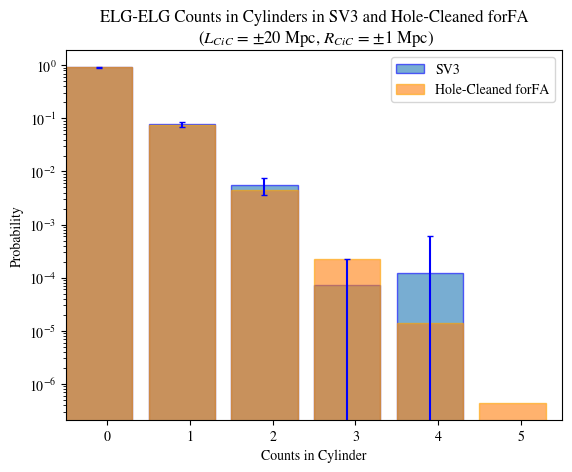

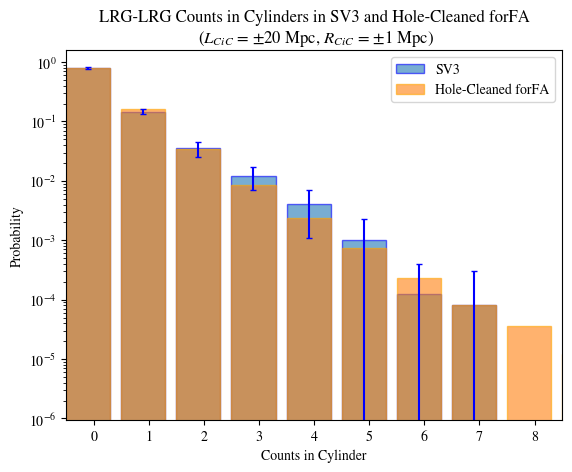

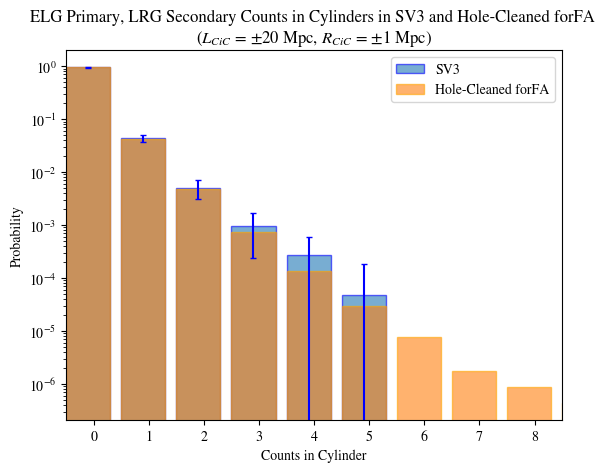

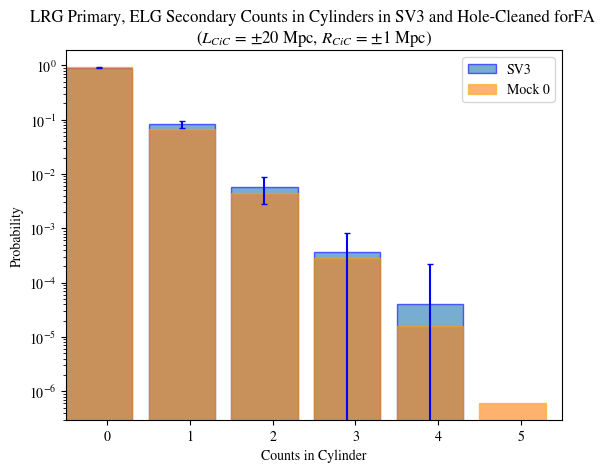

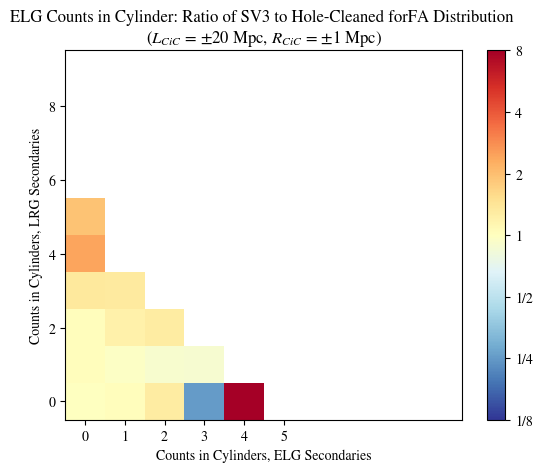

In [22]:
mocktable_elg = combined_elg_forFAcleaned
mocktable_lrg = combined_lrg_forFAcleaned
figdir = "figs_comparison"
mocknamelong = "Hole-Cleaned forFA"
compareMockSV3(mocktable_elg,mocktable_lrg, mocknamelong, figdir)

1.5356230912536393
1.0886593743849402
1.1194474028497339
1.6020698311692794


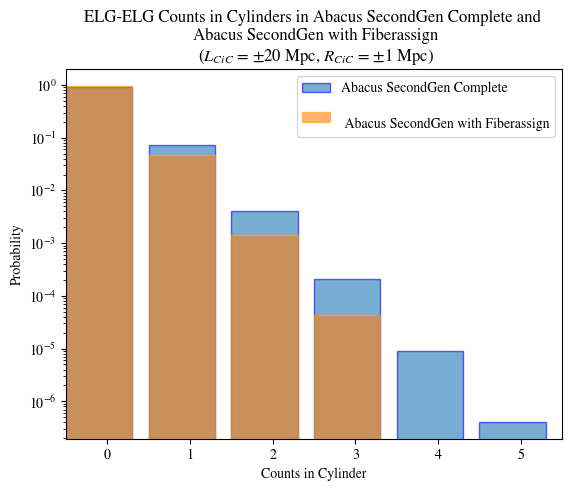

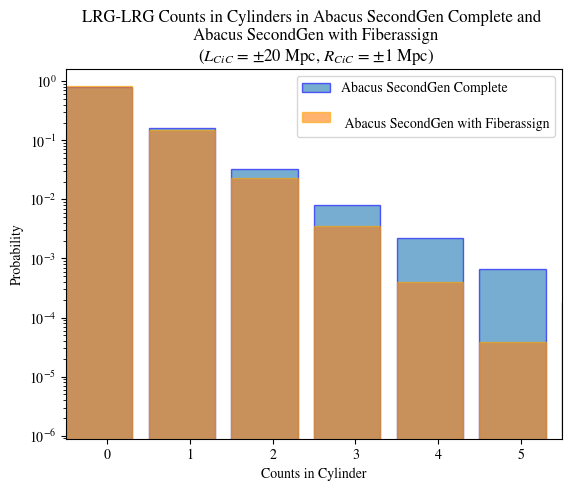

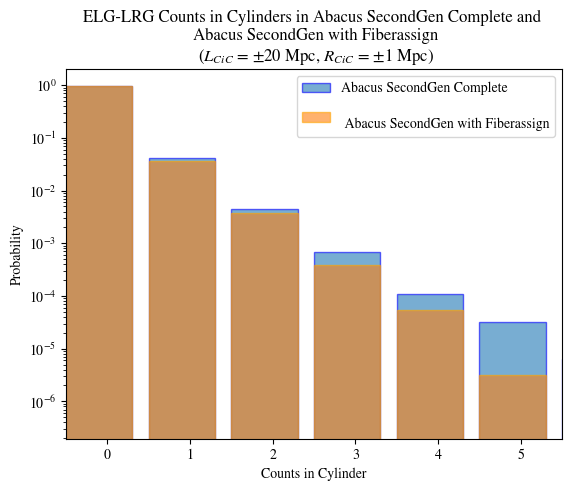

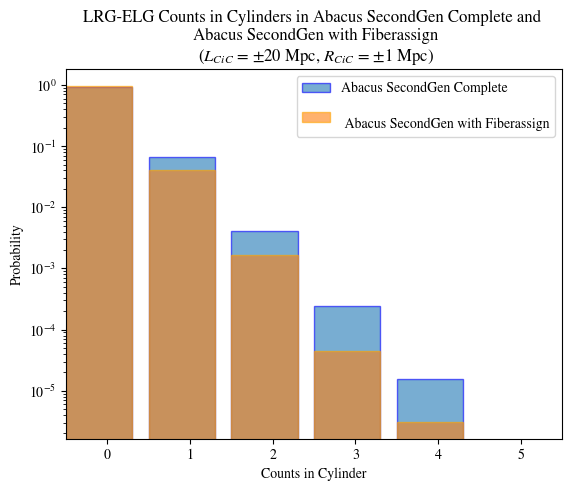

In [25]:
mock1_elg = combined_elg_forFAebits
mock2_elg = combined_elg_FFA
mock1_lrg = combined_lrg_forFAebits
mock2_lrg = combined_lrg_FFA
mockname1 = "Abacus SecondGen Complete"
mockname2 = "\n Abacus SecondGen with Fiberassign"
figtime = "compare_ffa"
figdir = "figsffa"
compareMockMock(mock1_elg,mock1_lrg, mock2_elg, mock2_lrg, 
                    mockname1, mockname2, figtag, figdir)

In [20]:
sv3elg_CiCerr,sv3lrg_CiCerr,sv3elglrg_CiCerr,sv3lrgelg_CiCerr,elgmultitracer_CiCerr,lrgmultitracer_CiCerr = bootstrapError(sv3elg,sv3lrg)

/tmp/ipykernel_1078655/236665807.py:10: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sv3elg_roshist = np.array([np.histogram(sv3elg_ros[i]["N_CiC"], bins = bins,
/tmp/ipykernel_1078655/236665807.py:12: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  sv3lrg_roshist = np.array([np.histogram(sv3lrg_ros[i]["N_CiC"], bins = bins,
/tmp/ipykernel_1078655/236665807.py:15: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you m

In [21]:
figdir = "figs_ebits/"
mocknamelong = "Abacus SecondGen forFA"
mocktable_elg = combined_elg_forFAebits
mocktable_lrg = combined_lrg_forFAebits
compareMockSV3(mocktable_elg,mocktable_lrg, mocknamelong, figdir)

NameError: name 'combined_elg_forFAebits' is not defined

/tmp/ipykernel_2163607/2045249849.py:98: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_2163607/2045249849.py:98: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_2163607/2045249849.py:110: RuntimeWarning: invalid value encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]


0.0008196367714938959
0.00012941633234114146
0.0


/tmp/ipykernel_2163607/2045249849.py:132: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_2163607/2045249849.py:132: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)


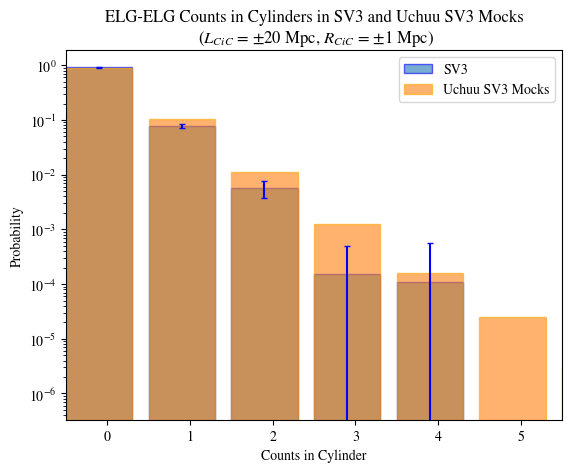

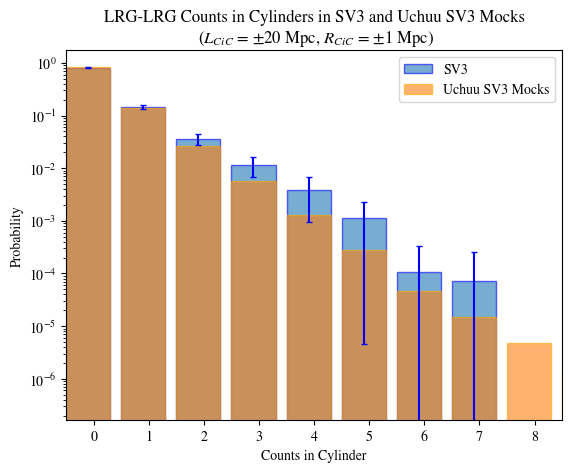

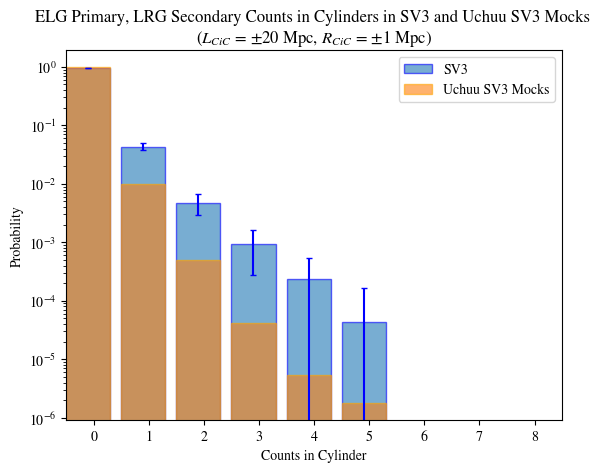

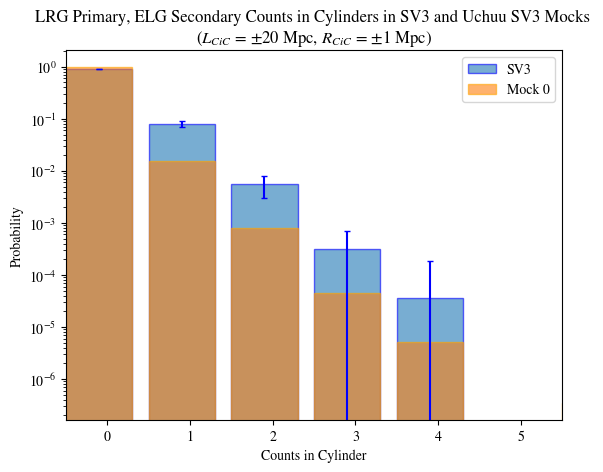

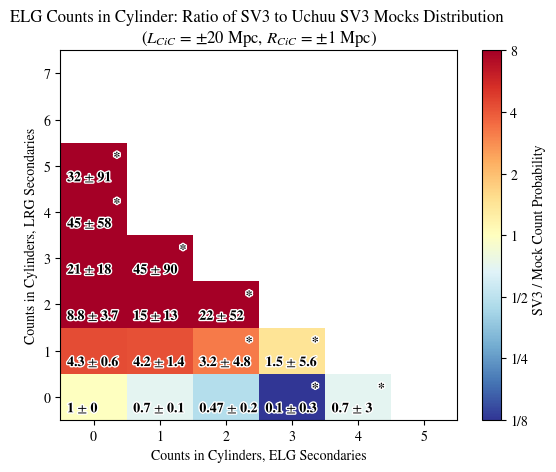

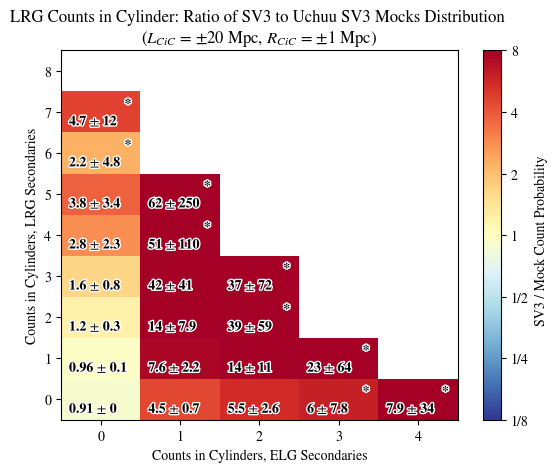

In [33]:
figdir = "figs_Uchuu/"
mocknamelong = "Uchuu SV3 Mocks"
mocktable_elg = uchuu_elg
mocktable_lrg = uchuu_lrg
compareMockSV3(mocktable_elg,mocktable_lrg, mocknamelong, figdir)

/tmp/ipykernel_2163607/2045249849.py:98: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_2163607/2045249849.py:98: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_2163607/2045249849.py:110: RuntimeWarning: invalid value encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]


0.0008196367714938959
0.00012941633234114146
0.0


/tmp/ipykernel_2163607/2045249849.py:132: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_2163607/2045249849.py:132: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)


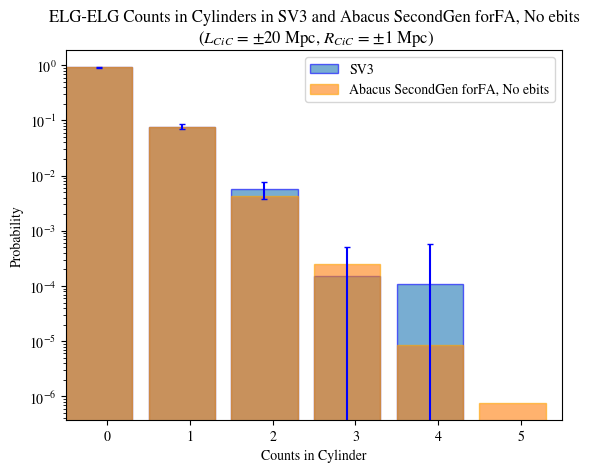

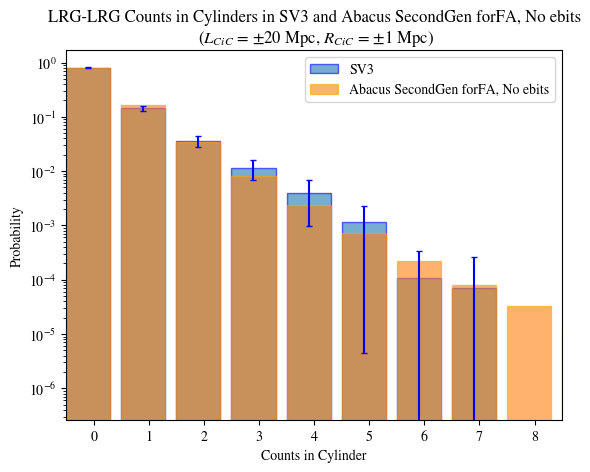

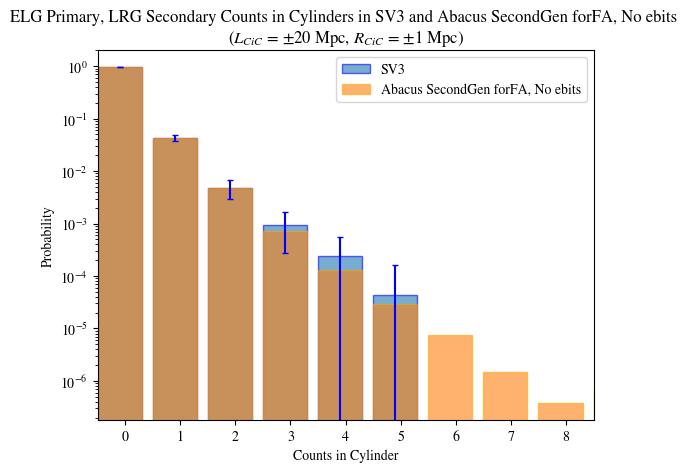

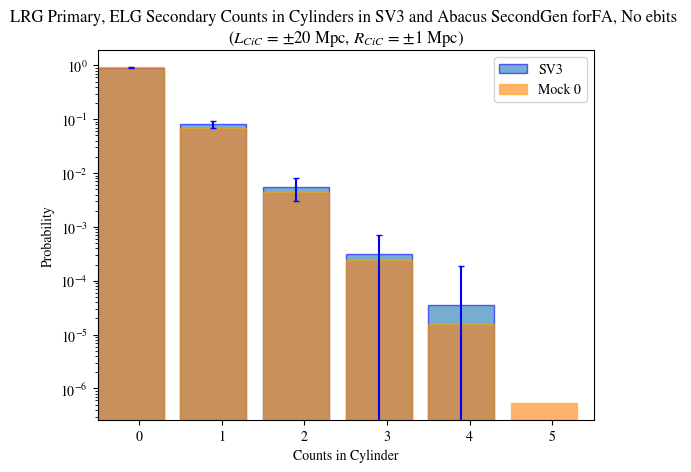

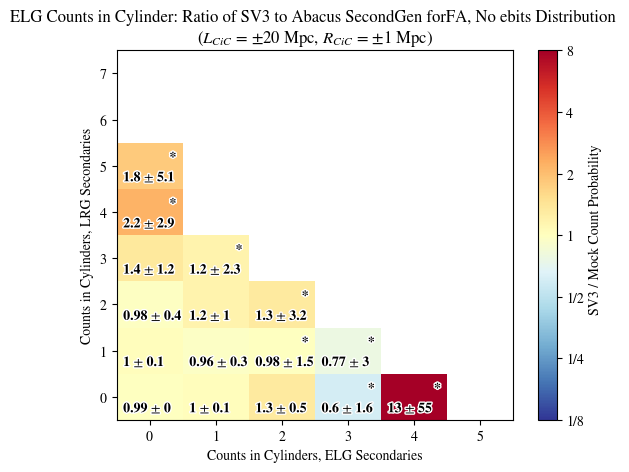

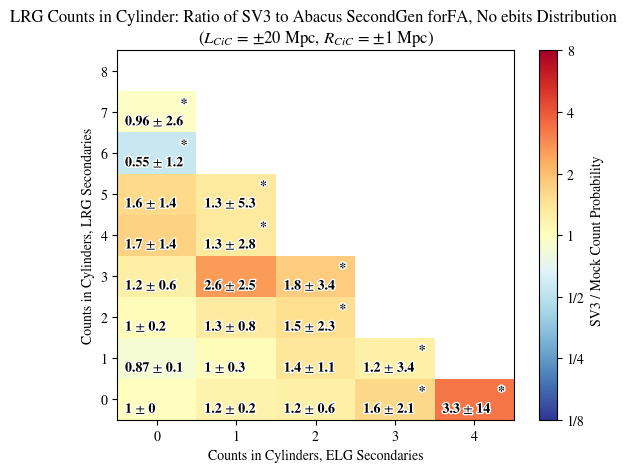

In [13]:
figdir = "figs_noebits/"
mocknamelong = "Abacus SecondGen forFA, No ebits"
mocktable_elg = combined_elg_forFAnoebits
mocktable_lrg = combined_lrg_forFAnoebits
compareMockSV3(mocktable_elg,mocktable_lrg, mocknamelong, figdir)

In [ ]:
mock1_elg = combined_elg_noimmask
mock1_lrg = combined_lrg_noimmask
mock2_elg = combined_elg_withholes
mock2_lrg = combined_lrg_withholes
mockname1 = "No Imaging Mask"
mockname2 = "With Imaging Mask"
figtag = "immask_comparison"
figdir = 'figs'
compareMockMock(mock1_elg,mock1_lrg, mock2_elg, mock2_lrg, 
                    mockname1, mockname2, figtag,figdir)

In [ ]:
mocktable_elg = combined_elg_forFA
mocktable_lrg = combined_lrg_forFA
mocknamelong = "Abacus forFA Mocks"
figdir = "figs_forFAR1L40/"
compareMockSV3(mocktable_elg, mocktable_lrg, mocknamelong, figdir)

/tmp/ipykernel_2353573/3733022861.py:97: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_2353573/3733022861.py:97: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_2353573/3733022861.py:109: RuntimeWarning: invalid value encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]


0.0008196367714938959
0.00012941633234114146
0.0


/tmp/ipykernel_2353573/3733022861.py:131: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_2353573/3733022861.py:131: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)


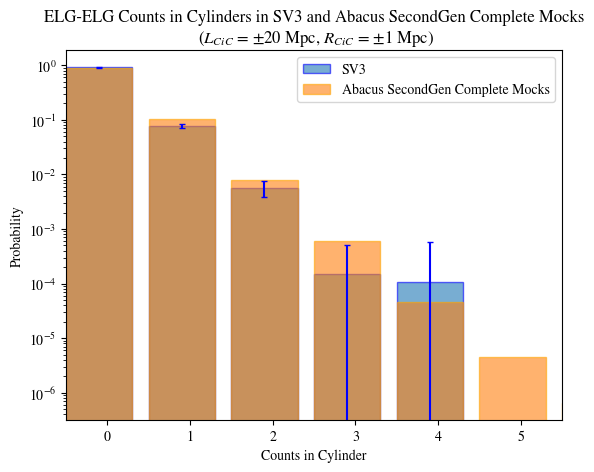

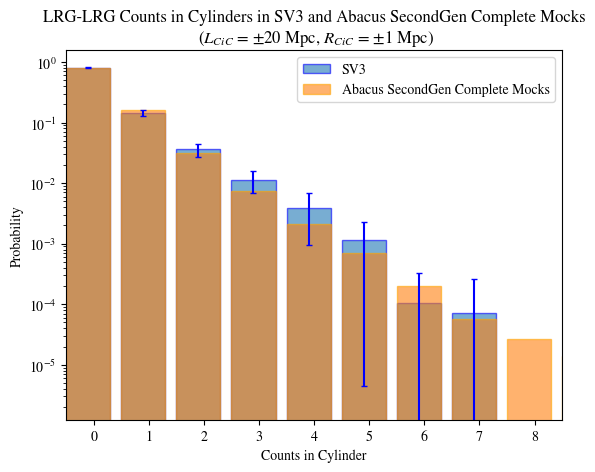

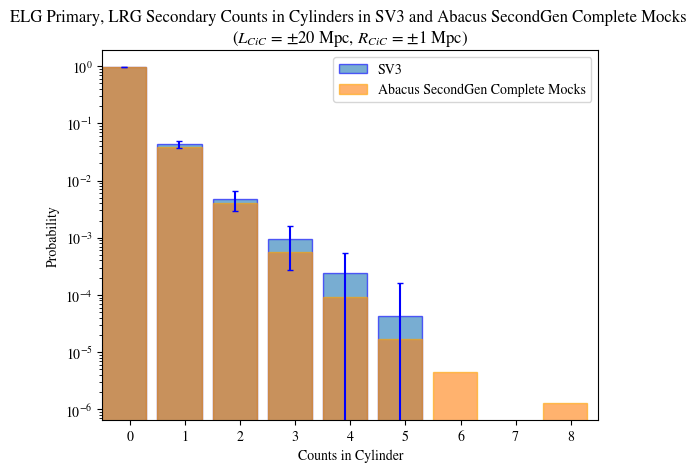

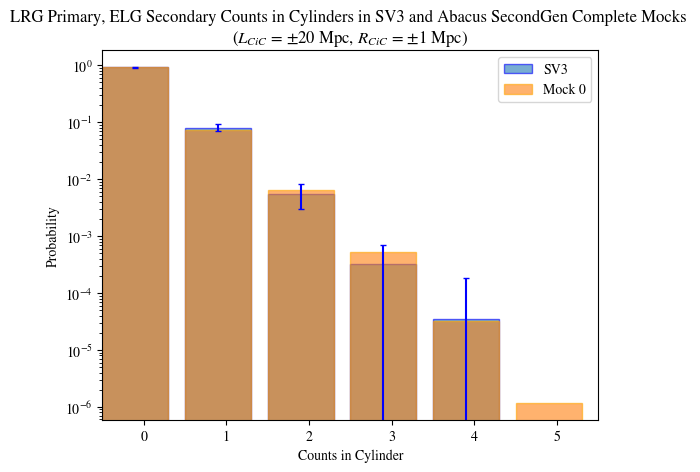

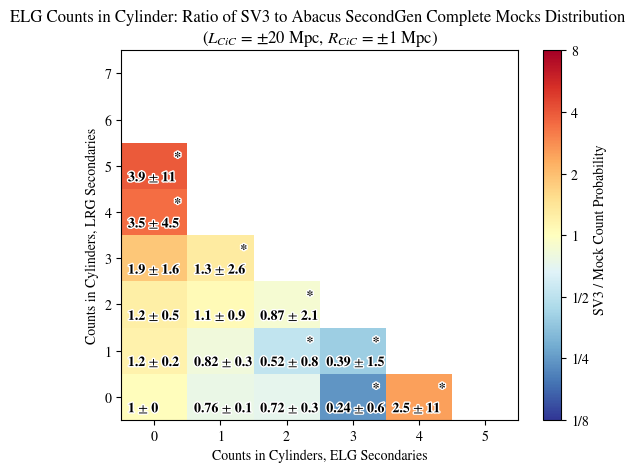

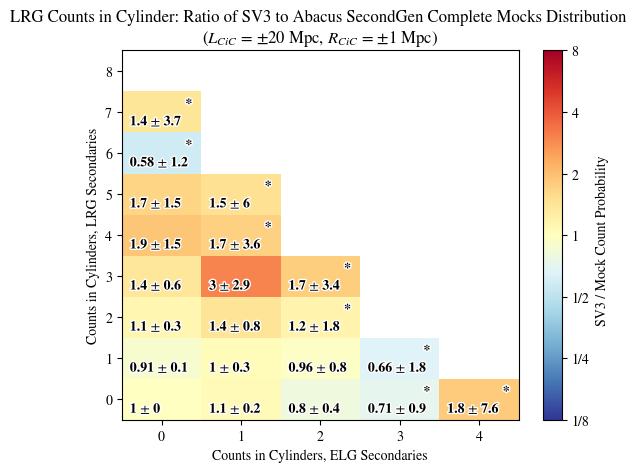

In [8]:
mocktable_elg = combined_elg
mocktable_lrg = combined_lrg
mocknamelong = "Abacus SecondGen Complete Mocks"
figdir = "figs_Abacus2Gen/"
compareMockSV3(mocktable_elg, mocktable_lrg, mocknamelong, figdir)

/tmp/ipykernel_166933/3733022861.py:97: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_166933/3733022861.py:97: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_166933/3733022861.py:109: RuntimeWarning: invalid value encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]
/tmp/ipykernel_166933/3733022861.py:109: RuntimeWarning: divide by zero encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]


0.0012202327433400982
0.00023120199347496597
5.137822077221466e-05


/tmp/ipykernel_166933/3733022861.py:131: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_166933/3733022861.py:131: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)


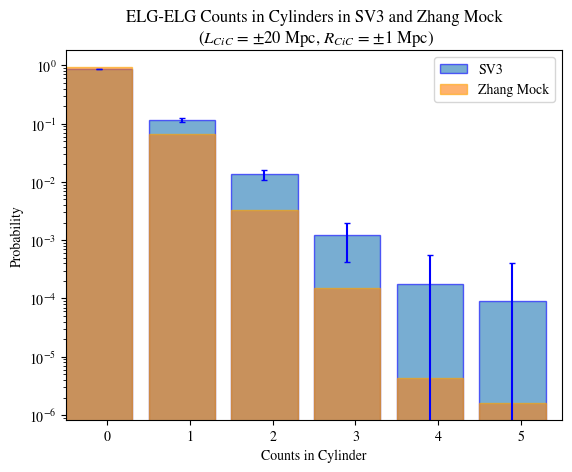

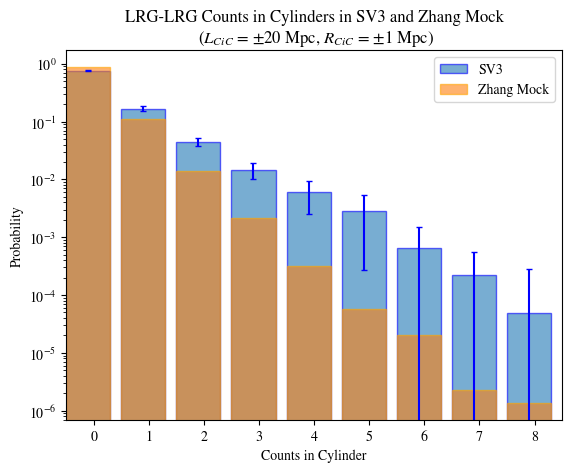

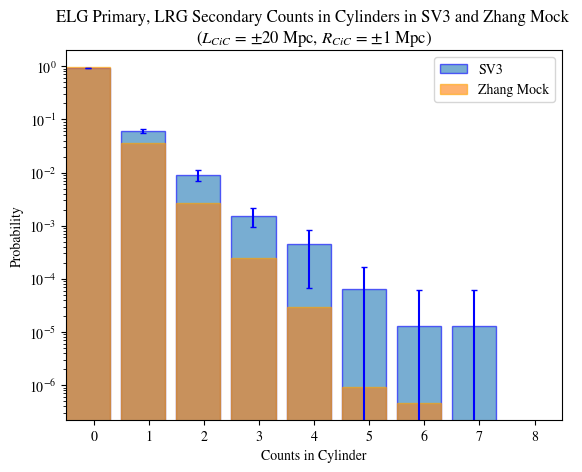

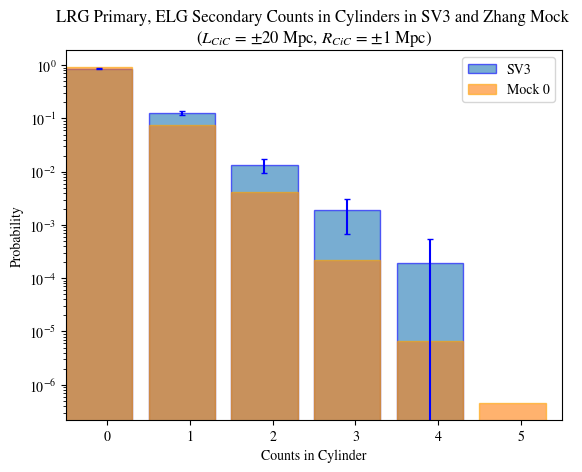

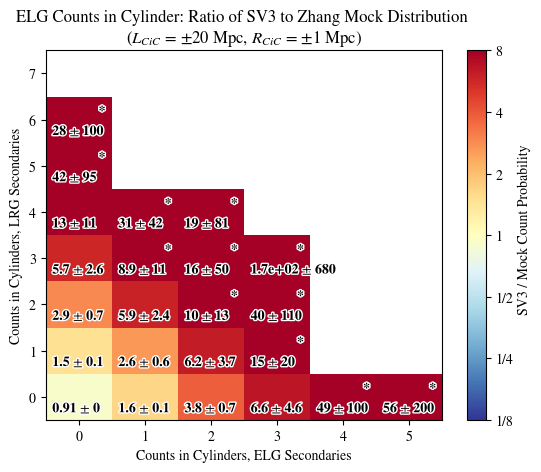

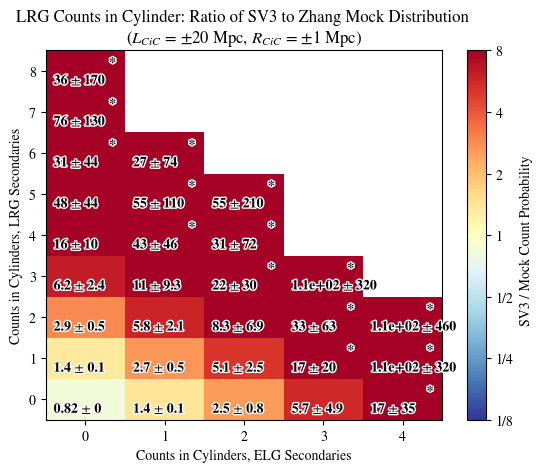

In [19]:
mocktable_elg = mockZhangelg
mocktable_lrg = mockZhanglrg
mocknamelong = "Zhang Mock"
figdir = "figs_ZhangR1L40/"
compareMockSV3(mocktable_elg, mocktable_lrg, mocknamelong, figdir)

/tmp/ipykernel_1523506/3733022861.py:97: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1523506/3733022861.py:97: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1523506/3733022861.py:109: RuntimeWarning: invalid value encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]
/tmp/ipykernel_1523506/3733022861.py:109: RuntimeWarning: divide by zero encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]


0.0012202327433400982
0.00023120199347496597
5.137822077221466e-05


/tmp/ipykernel_1523506/3733022861.py:131: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1523506/3733022861.py:131: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)


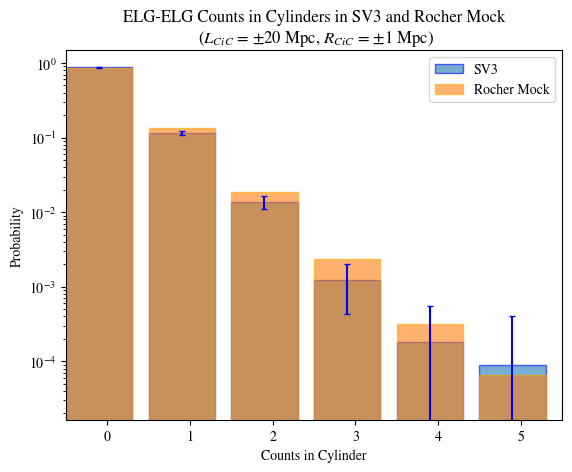

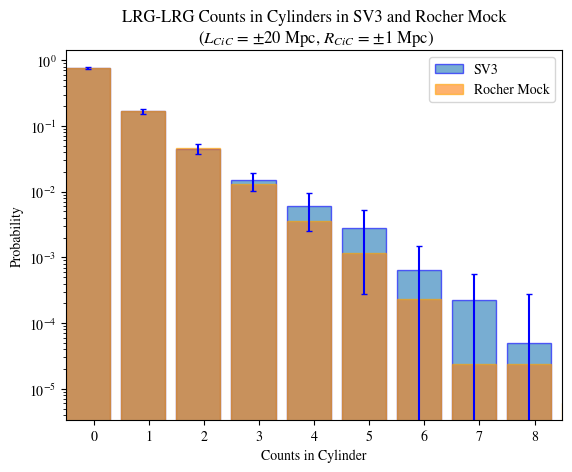

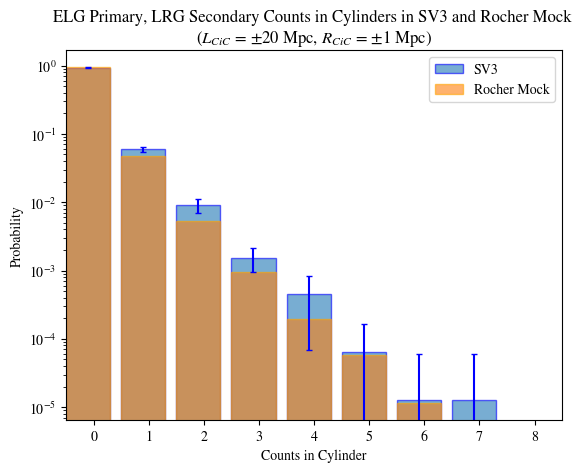

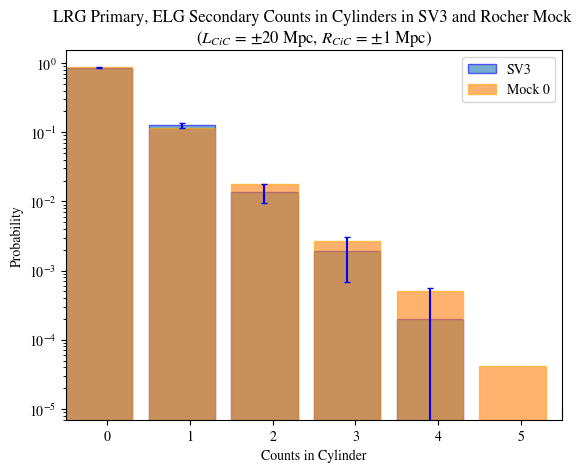

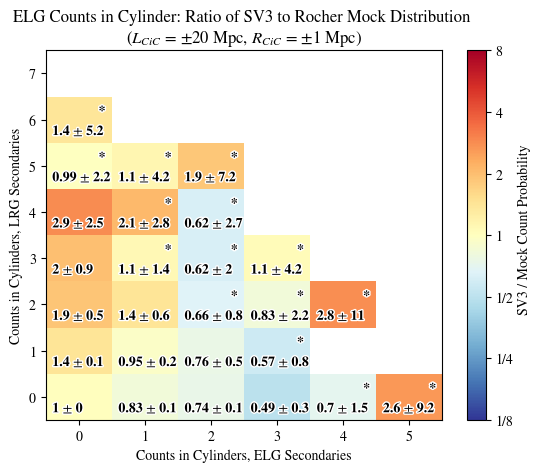

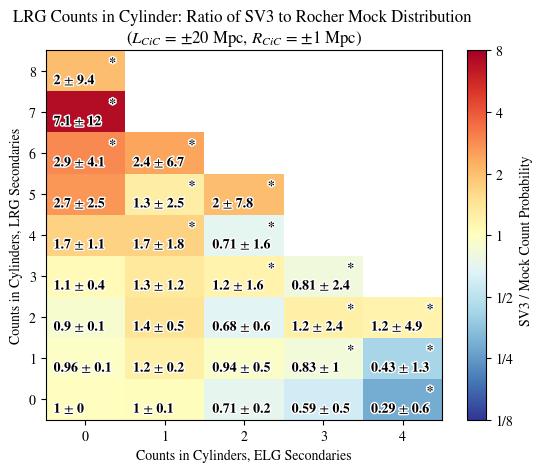

In [24]:
mocktable_elg = mockRocherelg
mocktable_lrg = mockRocherlrg
mocknamelong = "Rocher Mock"
figdir = "figs_RocherR1L40/"
compareMockSV3(mocktable_elg, mocktable_lrg, mocknamelong, figdir)

/tmp/ipykernel_1523506/3733022861.py:97: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1523506/3733022861.py:97: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1523506/3733022861.py:109: RuntimeWarning: invalid value encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]
/tmp/ipykernel_1523506/3733022861.py:109: RuntimeWarning: divide by zero encountered in double_scalars
  elgerr = np.ndenumerate([[elgmultitracer_CiCerr[i][j]/hist2[i][j] for j in range(maxcounts+1)]


0.0012202327433400982
0.00023120199347496597
5.137822077221466e-05


/tmp/ipykernel_1523506/3733022861.py:131: RuntimeWarning: divide by zero encountered in log
  diff = np.log(hist1)-np.log(hist2)
/tmp/ipykernel_1523506/3733022861.py:131: RuntimeWarning: invalid value encountered in subtract
  diff = np.log(hist1)-np.log(hist2)


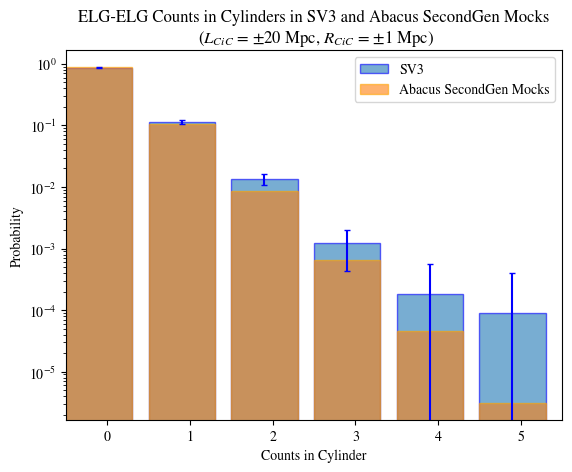

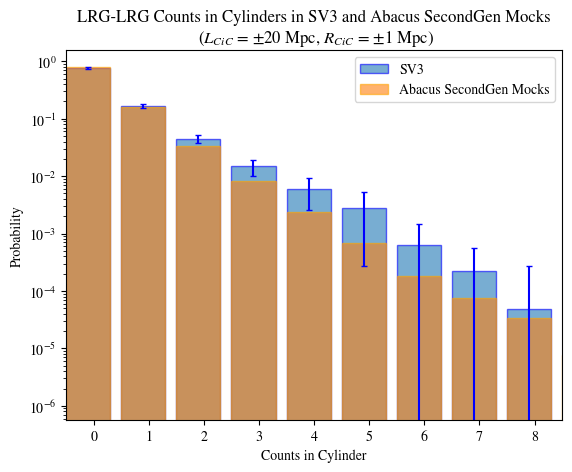

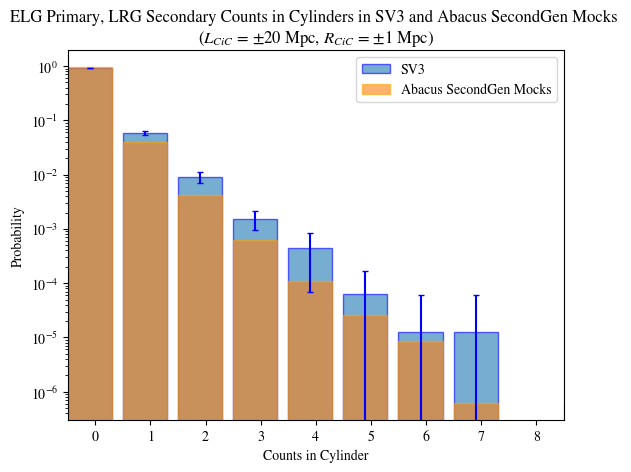

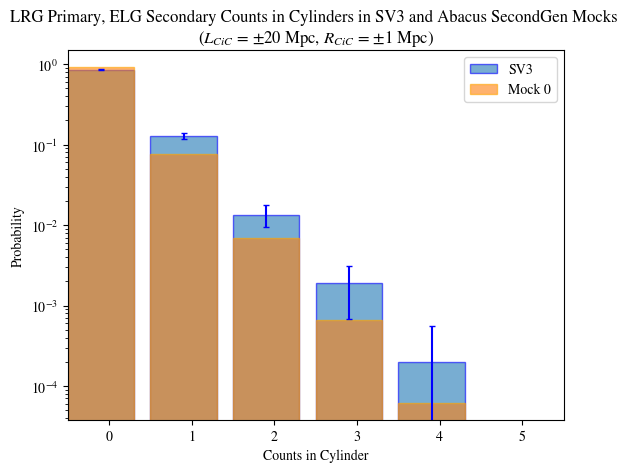

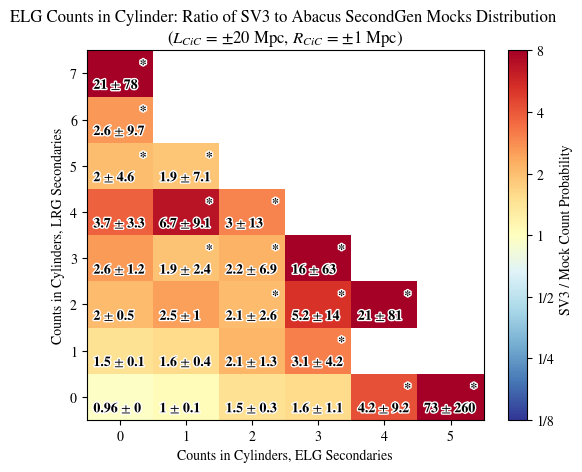

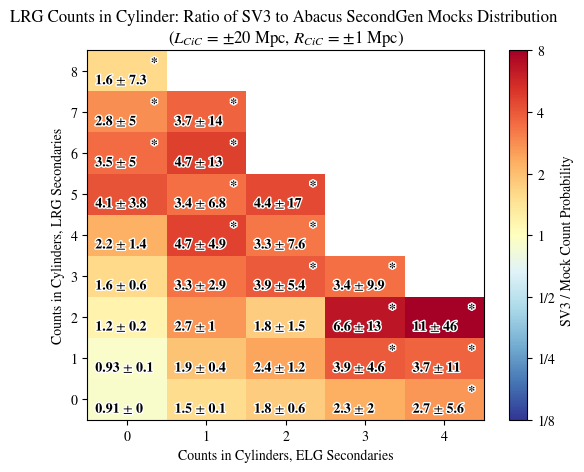

In [25]:
mocktable_elg = combined_elg
mocktable_lrg = combined_lrg
mocknamelong = "Abacus SecondGen Mocks"
figdir = "figs_Abacus2Gen/"
compareMockSV3(mocktable_elg, mocktable_lrg, mocknamelong, figdir)

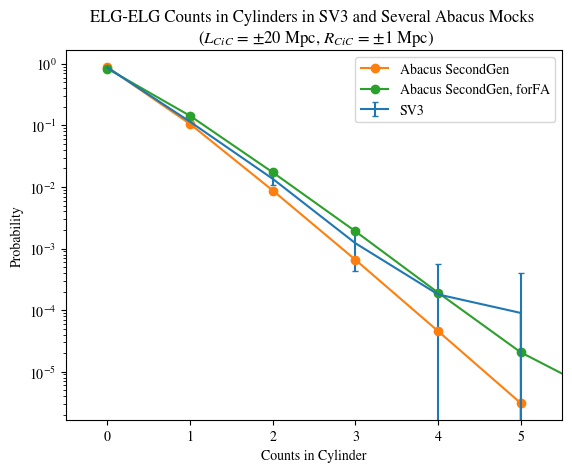

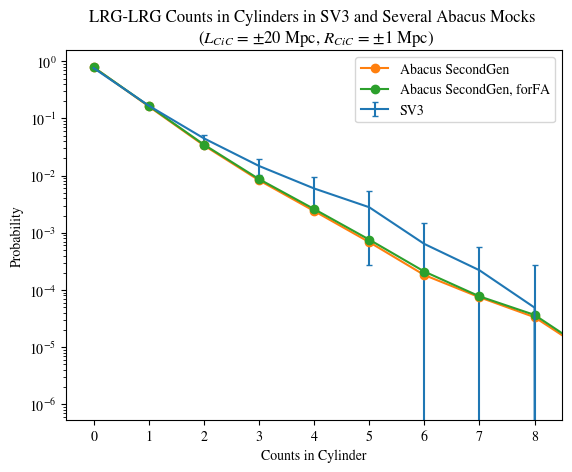

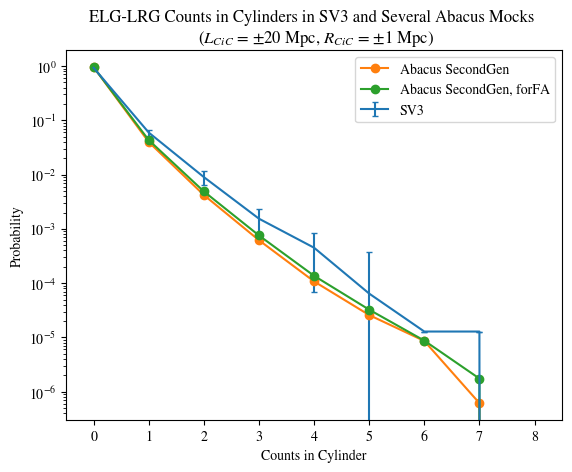

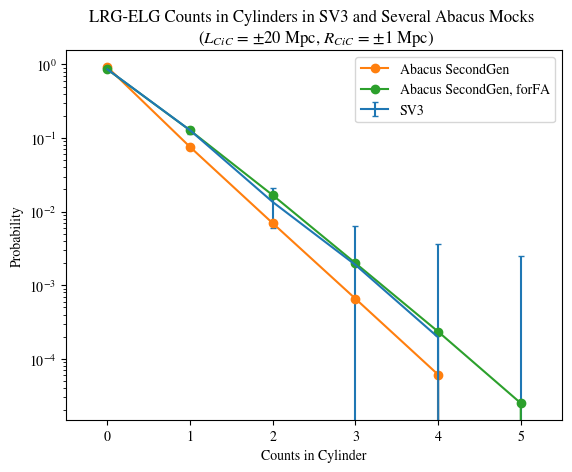

In [26]:
#plot Abacus with no angular cut, abacus with angular cut, forFA all together
err = [sv3elg_CiCerr, sv3lrg_CiCerr, sv3elg_CiCerr, sv3lrg_CiCerr]
lists = [[sv3elg['N_CiC'], sv3lrg['N_CiC'], sv3elg['N_lrgCiC'],sv3lrg['N_elgCiC']],
         [combined_elg['N_CiC'],combined_lrg['N_CiC'], combined_elg['N_lrgCiC'],combined_lrg['N_elgCiC']],
         [combined_elg_forFA['N_CiC'],combined_lrg_forFA['N_CiC'], combined_elg_forFA['N_lrgCiC'],combined_lrg_forFA['N_elgCiC']]]

names = ['SV3','Abacus SecondGen','Abacus SecondGen, forFA']
figdir = "figsAbacusComparison"
binmax = 24
plotnames = ['ELG_ELG','LRG_LRG','ELG_LRG','LRG_ELG']
fignames = ['ELG-ELG','LRG-LRG','ELG-LRG','LRG-ELG']
xmax = [5,8,8,5]

for i in range(4):
    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title(fignames[i]+" Counts in Cylinders in SV3 and Several Abacus Mocks \n"+r" ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    for j in range(3):
        hist, bins = np.histogram(lists[j][i], bins = bins, density = True)
        if j == 0:
            plt.errorbar(bins[:-1]+0.5, hist,label=names[j], yerr = err[i],capsize=2)
        else: 
            plt.plot(bins[:-1]+0.5, hist, '-o',label=names[j])

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,xmax[i] + 0.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+"/"+plotnames[i]+"Abacus_"+figtag+".png")


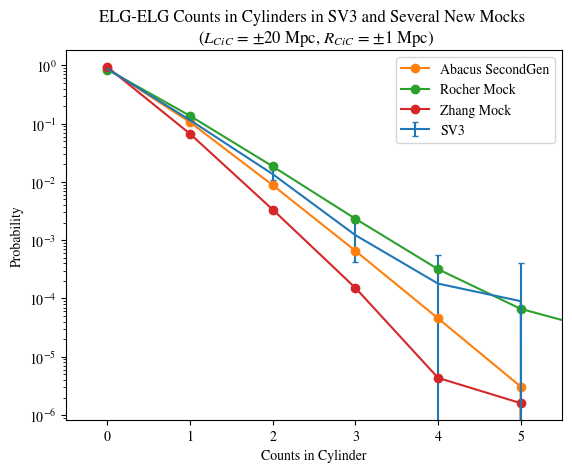

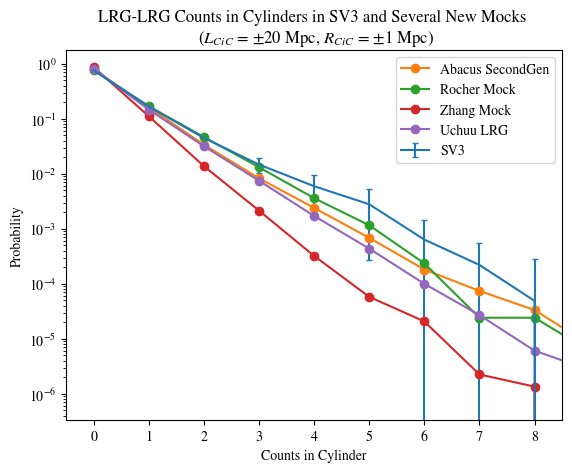

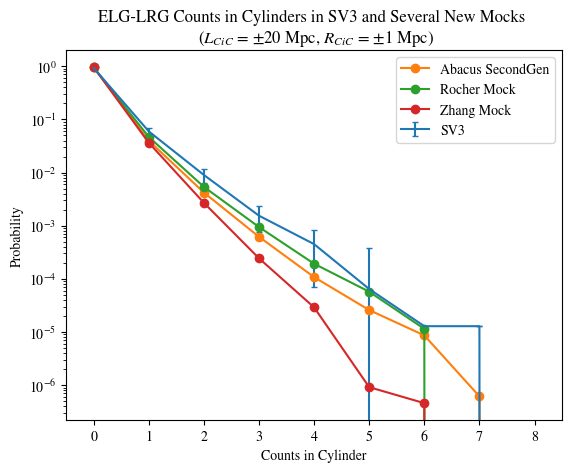

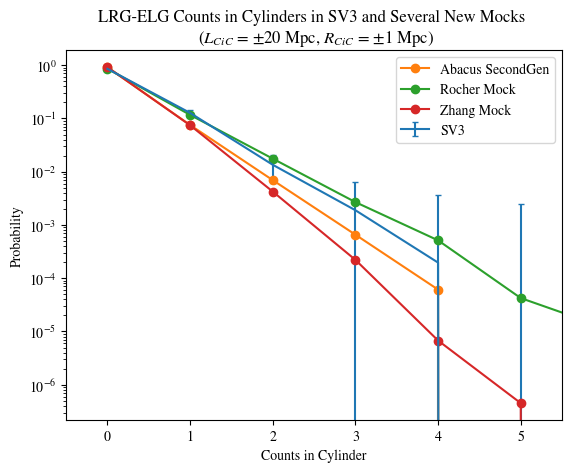

In [27]:
figdir = "figs_comparison/"
#plot Abacus with no angular cut, abacus with angular cut, forFA all together
err = [sv3elg_CiCerr, sv3lrg_CiCerr, sv3elg_CiCerr, sv3lrg_CiCerr]
lists = [[sv3elg['N_CiC'], sv3lrg['N_CiC'], sv3elg['N_lrgCiC'],sv3lrg['N_elgCiC']],
         [combined_elg['N_CiC'],combined_lrg['N_CiC'], combined_elg['N_lrgCiC'],combined_lrg['N_elgCiC']],
         [mockRocherelg['N_CiC'],mockRocherlrg['N_CiC'], mockRocherelg['N_lrgCiC'],mockRocherlrg['N_elgCiC']],
         [mockZhangelg['N_CiC'],mockZhanglrg['N_CiC'], mockZhangelg['N_lrgCiC'],mockZhanglrg['N_elgCiC']]]

names = ['SV3','Abacus SecondGen','Rocher Mock','Zhang Mock']
binmax = 24
plotnames = ['ELG_ELG','LRG_LRG','ELG_LRG','LRG_ELG']
fignames = ['ELG-ELG','LRG-LRG','ELG-LRG','LRG-ELG']
xmax = [5,8,8,5]

for i in range(4):
    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title(fignames[i]+" Counts in Cylinders in SV3 and Several New Mocks \n"+r" ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    for j in range(4):
        hist, bins = np.histogram(lists[j][i], bins = bins, density = True)
        if j == 0:
            plt.errorbar(bins[:-1]+0.5, hist,label=names[j], yerr = err[i],capsize=2)
        else: 
            plt.plot(bins[:-1]+0.5, hist, '-o',label=names[j])
    if i == 1:
        hist, bins = np.histogram(mockUchuulrg['N_CiC'], bins = bins, density = True)
        plt.plot(bins[:-1]+0.5, hist, '-o',label="Uchuu LRG")

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability")
    plt.xlim(-0.5,xmax[i] + 0.5)

    plt.legend()
    plt.yscale("log")
    plt.savefig(figdir+plotnames[i]+"_"+figtag+".png")


/tmp/ipykernel_2163607/3435628567.py:26: RuntimeWarning: invalid value encountered in true_divide
  plt.plot(bins[:-1]+0.5, hist/histnoholes, '-o',label=names[j])


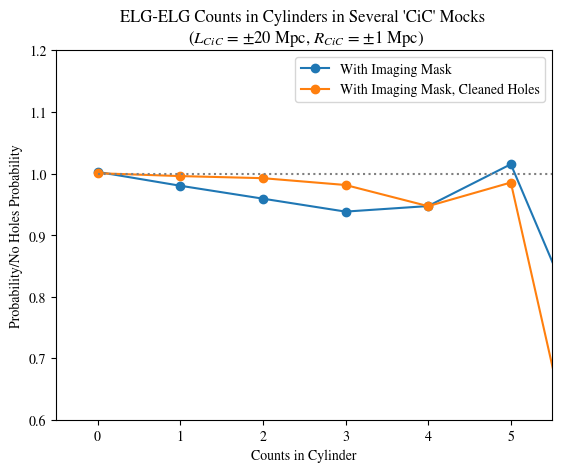

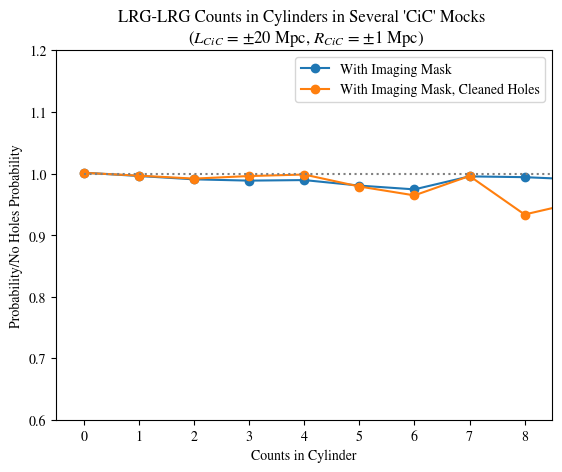

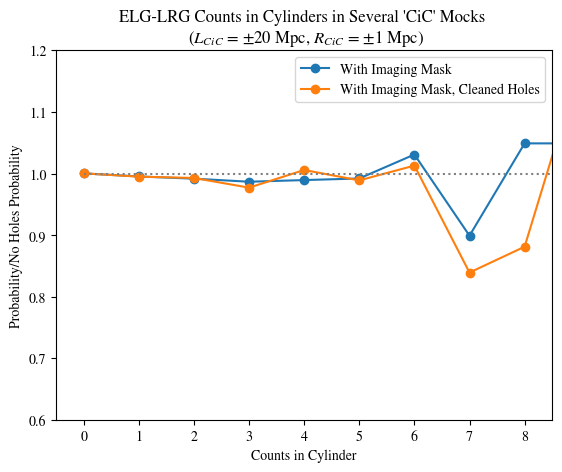

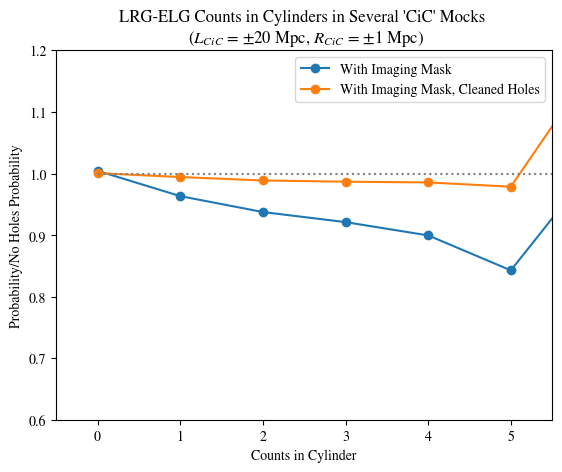

In [37]:
figdir = "figs_AurelioCiC/"
#plot Abacus with no angular cut, abacus with angular cut, forFA all together
err = [sv3elg_CiCerr, sv3lrg_CiCerr, sv3elg_CiCerr, sv3lrg_CiCerr]
lists = [[combined_elg_noimmask['N_CiC'], combined_lrg_noimmask['N_CiC'], 
          combined_elg_noimmask['N_lrgCiC'],combined_lrg_noimmask['N_elgCiC']],
         [combined_elg_withholes['N_CiC'], combined_lrg_withholes['N_CiC'], 
          combined_elg_withholes['N_lrgCiC'],combined_lrg_withholes['N_elgCiC']],
            [combined_elg_holeclean['N_CiC'], combined_lrg_holeclean['N_CiC'], 
          combined_elg_holeclean['N_lrgCiC'],combined_lrg_holeclean['N_elgCiC']]]

names = ['No Imaging Mask','With Imaging Mask','With Imaging Mask, Cleaned Holes']
binmax = 24
plotnames = ['ELG_ELG','LRG_LRG','ELG_LRG','LRG_ELG']
fignames = ['ELG-ELG','LRG-LRG','ELG-LRG','LRG-ELG']
xmax = [5,8,8,5]
bins = np.arange(-0.5,binmax+0.5,step=1)

for i in range(4):
    fig,ax = plt.subplots(1)
    ax.set_xticks(bins+0.5)
    plt.title(fignames[i]+" Counts in Cylinders in Several 'CiC' Mocks \n"+r" ($L_{CiC}$ = $\pm$"+"20"+" Mpc, $R_{CiC}$ = $\pm$"+R+" Mpc)")

    histnoholes, bins = np.histogram(lists[0][i], bins = bins, density = True)
    for j in np.arange(1,3):
        hist, bins = np.histogram(lists[j][i], bins = bins, density = True)
        plt.plot(bins[:-1]+0.5, hist/histnoholes, '-o',label=names[j])
    plt.plot(bins[:-1]+0.5, np.repeat(1,len(bins[:-1])),linestyle = 'dotted',color='gray')

    plt.xlabel("Counts in Cylinder")
    plt.ylabel("Probability/No Holes Probability")
    plt.xlim(-0.5,xmax[i] + 0.5)

    plt.legend()
    #plt.yscale("log")
    plt.ylim(0.6,1.2)
    plt.savefig(figdir+plotnames[i]+"_"+figtag+".png")
